## Imports #



In [1]:
from forecast_flag import *
from input_generation import *

## Data Generation 

In [2]:
# Generate data with realistic scenarios to demonstrate Forecast Flag impact
sales, stock, sell_in, sell_out, ASSORT_MATRIX, LOCATION_LIFE = generate_input_ilp('2002-12-01','2003-12-01')

In [3]:
SALES_UPDATE_FF, STOCK_UPDATE_FF, SELL_IN_UPDATE_FF, SELL_OUT_UPDATE_FF, ASSORT_MATRIX_UPDATE_FF, QUADRUPLES_DELETE = incremental_load_preparation(
    sales,
    stock,
    sell_in,
    sell_out,
    ASSORT_MATRIX,
    LOCATION_LIFE,
    '2002-12-01',
    '2003-12-01'
)

In [4]:
SALES_ENRICHED, STOCK_ENRICHED = adding_fields(SALES_UPDATE_FF, STOCK_UPDATE_FF, ASSORT_MATRIX_UPDATE_FF)

In [5]:
FF_FACT_DATES = calculate_fact_dates(SALES_ENRICHED, SELL_IN_UPDATE_FF, SELL_OUT_UPDATE_FF)


In [6]:
FF_ASSORT_DATES = calculate_assortment_dates(ASSORT_MATRIX_UPDATE_FF)


c:\Users\sotov\Downloads\ForecastFlag\forecast_flag.py:654: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  work = grouped.apply(_fill_end).reset_index(drop=True)


In [7]:
FF_LIFE_DATES = process_life_cycles()


## Forecast Flag - Business Value Demonstration

This section demonstrates how the Forecast Flag improves forecast reliability by filtering out invalid or unreliable data periods.


In [12]:
FF_FORECAST = calculate_forecast_flag(
    FF_FACT_DATES,
    FF_ASSORT_DATES,
    FF_LIFE_DATES,
    FORECAST_FLAG=None,
    QUADRUPLES_DELETE=QUADRUPLES_DELETE
)


c:\Users\sotov\Downloads\ForecastFlag\forecast_flag.py:850: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing, ff_dates_merged], axis=0, ignore_index=True)


In [13]:
import matplotlib.pyplot as plt
import numpy as np


### Data Quality Impact Analysis

Analyzing how invalid data periods would mislead forecasting without explicitly building forecast models.


FORECAST FLAG FILTERING ANALYSIS

1. ITEMS FLAGGED FOR DELETION IN INITIAL TABLES
📋 ASSORT_MATRIX:
   Total rows: 366
   Rows with del_flag == 1: 73 (19.9%)
   Unique product-location combos marked for deletion: 73 (19.9% of input)

📋 LOCATION_LIFE:
   Total rows: 366
   Rows with del_flag == 1: 73 (19.9%)
   Unique product-location combos marked for deletion: 73 (19.9% of input)

📊 TOTAL UNIQUE COMBINATIONS MARKED FOR DELETION:
   Unique product-location combos: 121 (33.1% of input)

2. ITEMS DELETED IN SALES TABLE AFTER FORECAST FLAG
📊 SALES TABLE AFTER FORECAST FLAG:
   Initial combinations: 366 (100.0%)
   ✅ Kept (valid): 245 (66.9%)
   ❌ Filtered out (deleted): 121 (33.1%)
   Final combinations: 245

3. IRRELEVANT DATA ANALYSIS
📊 BEFORE FORECAST FLAG (Initial Sales Data):
   Total combinations: 366 (100.0%)
   Includes 121 irrelevant combos marked for deletion (33.1%)

📊 AFTER FORECAST FLAG (Filtered Sales Data):
   Total combinations: 245 (100.0%)
   ✅ No irrelevant data remainin

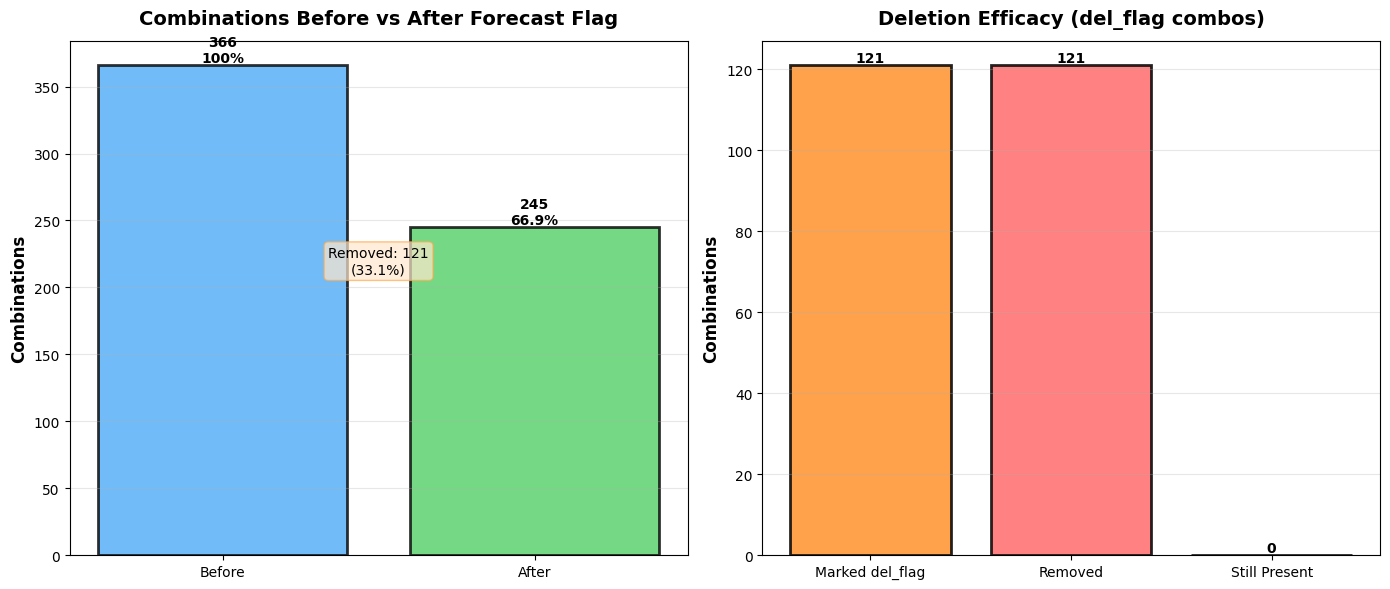

📊 Raw data (before): 366 combinations
   Marked for deletion (del_flag==1): 121
   Removed after Forecast Flag: 121 (33.1%)
   Still present but marked del_flag==1: 0


In [16]:
print("=" * 80)
print("FORECAST FLAG FILTERING ANALYSIS")
print("=" * 80)

# Prepare data for comparison
sales_cols = sales.columns.tolist()
orig_product_col = next((col for col in sales_cols if col.upper() == 'PRODUCT_ID'), None)
orig_location_col = next((col for col in sales_cols if col.upper() == 'LOCATION_ID'), None)

if orig_product_col is None or orig_location_col is None:
    raise ValueError(f"sales must contain PRODUCT_ID and LOCATION_ID columns. Found: {sales_cols}")

# INPUT: All product-location combinations from original sales data
input_combos = sales[[orig_product_col, orig_location_col]].drop_duplicates().copy()
input_combos.columns = ['PRODUCT_ID', 'LOCATION_ID']
input_combos['PRODUCT_ID'] = pd.to_numeric(input_combos['PRODUCT_ID'], errors='coerce').astype('Int64')
input_combos['LOCATION_ID'] = pd.to_numeric(input_combos['LOCATION_ID'], errors='coerce').astype('Int64')
input_combos = input_combos.dropna().reset_index(drop=True)

# OUTPUT: All product-location combinations that made it through Forecast Flag
output_cols = FF_FORECAST.columns.tolist()
ff_product_col = next((col for col in output_cols if col.upper() == 'PRODUCT_ID'), None)
ff_location_col = next((col for col in output_cols if col.upper() == 'LOCATION_ID'), None)

if ff_product_col is None or ff_location_col is None:
    raise ValueError(f"FF_FORECAST must contain PRODUCT_ID and LOCATION_ID columns. Found: {output_cols}")

output_combos = FF_FORECAST[[ff_product_col, ff_location_col]].drop_duplicates().copy()
output_combos.columns = ['PRODUCT_ID', 'LOCATION_ID']
output_combos['PRODUCT_ID'] = pd.to_numeric(output_combos['PRODUCT_ID'], errors='coerce').astype('Int64')
output_combos['LOCATION_ID'] = pd.to_numeric(output_combos['LOCATION_ID'], errors='coerce').astype('Int64')
output_combos = output_combos.dropna().reset_index(drop=True)

# Find filtered combinations
merged = input_combos.merge(output_combos, on=['PRODUCT_ID', 'LOCATION_ID'], how='outer', indicator=True)
should_not_forecast = merged[merged['_merge'] == 'left_only'][['PRODUCT_ID', 'LOCATION_ID']].copy()
valid_combos_ff = merged[merged['_merge'] == 'both'][['PRODUCT_ID', 'LOCATION_ID']].copy()

# Calculate counts
total_input_combos = len(input_combos)
total_output_combos = len(output_combos)
filtered_count = len(should_not_forecast)
valid_count = len(valid_combos_ff)

# 1) Count percentage of items flagged del_flag == 1 in initial tables
print("\n" + "=" * 80)
print("1. ITEMS FLAGGED FOR DELETION IN INITIAL TABLES")
print("=" * 80)

assort_cols = ASSORT_MATRIX.columns.tolist()
assort_prod = next((col for col in assort_cols if col.upper() == 'PRODUCT_ID'), None)
assort_loc = next((col for col in assort_cols if col.upper() == 'LOCATION_ID'), None)
assort_del_flag = next((col for col in assort_cols if col.upper() in ['DEL_FLAG', 'DELETE_FLG', 'DELETE_FLAG']), None)

assort_del_count = 0
assort_total = 0
assort_del_combos = pd.DataFrame()

if assort_prod and assort_loc and assort_del_flag:
    assort_total = len(ASSORT_MATRIX)
    assort_del_count = len(ASSORT_MATRIX[ASSORT_MATRIX[assort_del_flag] == 1])
    assort_del_combos = ASSORT_MATRIX[ASSORT_MATRIX[assort_del_flag] == 1][[assort_prod, assort_loc]].drop_duplicates()
    assort_del_combos.columns = ['PRODUCT_ID', 'LOCATION_ID']
    assort_del_combos['PRODUCT_ID'] = pd.to_numeric(assort_del_combos['PRODUCT_ID'], errors='coerce').astype('Int64')
    assort_del_combos['LOCATION_ID'] = pd.to_numeric(assort_del_combos['LOCATION_ID'], errors='coerce').astype('Int64')
    assort_del_combos = assort_del_combos.dropna().reset_index(drop=True)
    assort_del_pct = (assort_del_count / assort_total * 100) if assort_total > 0 else 0
    assort_combo_del_pct = (len(assort_del_combos) / total_input_combos * 100) if total_input_combos > 0 else 0
    
    print(f"📋 ASSORT_MATRIX:")
    print(f"   Total rows: {assort_total:,}")
    print(f"   Rows with del_flag == 1: {assort_del_count:,} ({assort_del_pct:.1f}%)")
    print(f"   Unique product-location combos marked for deletion: {len(assort_del_combos):,} ({assort_combo_del_pct:.1f}% of input)")

life_cols = LOCATION_LIFE.columns.tolist()
life_prod = next((col for col in life_cols if col.upper() == 'PRODUCT_ID'), None)
life_loc = next((col for col in life_cols if col.upper() == 'LOCATION_ID'), None)
life_del_flag = next((col for col in life_cols if col.upper() in ['DEL_FLAG', 'DELETE_FLG', 'DELETE_FLAG']), None)

life_del_count = 0
life_total = 0
life_del_combos = pd.DataFrame()

if life_prod and life_loc and life_del_flag:
    life_total = len(LOCATION_LIFE)
    life_del_count = len(LOCATION_LIFE[LOCATION_LIFE[life_del_flag] == 1])
    life_del_combos = LOCATION_LIFE[LOCATION_LIFE[life_del_flag] == 1][[life_prod, life_loc]].drop_duplicates()
    life_del_combos.columns = ['PRODUCT_ID', 'LOCATION_ID']
    life_del_combos['PRODUCT_ID'] = pd.to_numeric(life_del_combos['PRODUCT_ID'], errors='coerce').astype('Int64')
    life_del_combos['LOCATION_ID'] = pd.to_numeric(life_del_combos['LOCATION_ID'], errors='coerce').astype('Int64')
    life_del_combos = life_del_combos.dropna().reset_index(drop=True)
    life_del_pct = (life_del_count / life_total * 100) if life_total > 0 else 0
    life_combo_del_pct = (len(life_del_combos) / total_input_combos * 100) if total_input_combos > 0 else 0
    
    print(f"\n📋 LOCATION_LIFE:")
    print(f"   Total rows: {life_total:,}")
    print(f"   Rows with del_flag == 1: {life_del_count:,} ({life_del_pct:.1f}%)")
    print(f"   Unique product-location combos marked for deletion: {len(life_del_combos):,} ({life_combo_del_pct:.1f}% of input)")

# Combined unique combos marked for deletion (union of both)
all_del_combos = pd.concat([assort_del_combos, life_del_combos], ignore_index=True).drop_duplicates()
total_del_combos = len(all_del_combos)
total_del_pct = (total_del_combos / total_input_combos * 100) if total_input_combos > 0 else 0
print(f"\n📊 TOTAL UNIQUE COMBINATIONS MARKED FOR DELETION:")
print(f"   Unique product-location combos: {total_del_combos:,} ({total_del_pct:.1f}% of input)")

# 2) Count percentage of items deleted in sales table after Forecast Flag
print("\n" + "=" * 80)
print("2. ITEMS DELETED IN SALES TABLE AFTER FORECAST FLAG")
print("=" * 80)

filtered_pct = (filtered_count / total_input_combos * 100) if total_input_combos > 0 else 0
remaining_pct = (valid_count / total_input_combos * 100) if total_input_combos > 0 else 0

print(f"📊 SALES TABLE AFTER FORECAST FLAG:")
print(f"   Initial combinations: {total_input_combos:,} (100.0%)")
print(f"   ✅ Kept (valid): {valid_count:,} ({remaining_pct:.1f}%)")
print(f"   ❌ Filtered out (deleted): {filtered_count:,} ({filtered_pct:.1f}%)")
print(f"   Final combinations: {total_output_combos:,}")

# 3) Check how much irrelevant data was and is now included in sales table
print("\n" + "=" * 80)
print("3. IRRELEVANT DATA ANALYSIS")
print("=" * 80)

print(f"📊 BEFORE FORECAST FLAG (Initial Sales Data):")
print(f"   Total combinations: {total_input_combos:,} (100.0%)")
print(f"   Includes {total_del_combos:,} irrelevant combos marked for deletion ({total_del_pct:.1f}%)")

# After Forecast Flag: Only combinations that should have been filtered but weren't
irrelevant_after_combos = output_combos.merge(all_del_combos, on=['PRODUCT_ID', 'LOCATION_ID'], how='inner') if len(all_del_combos) > 0 else pd.DataFrame(columns=['PRODUCT_ID', 'LOCATION_ID'])
irrelevant_after_count = len(irrelevant_after_combos)
irrelevant_after_pct = (irrelevant_after_count / total_output_combos * 100) if total_output_combos > 0 else 0

print(f"\n📊 AFTER FORECAST FLAG (Filtered Sales Data):")
print(f"   Total combinations: {total_output_combos:,} (100.0%)")
if irrelevant_after_count > 0:
    print(f"   ⚠️  Still includes {irrelevant_after_count:,} irrelevant combos ({irrelevant_after_pct:.1f}%)")
    print(f"      (These were marked del_flag == 1 but weren't filtered)")
else:
    print(f"   ✅ No irrelevant data remaining (all del_flag == 1 combos were filtered)")

# Calculate cleanup effectiveness
if total_del_combos > 0:
    cleanup_rate = ((total_del_combos - irrelevant_after_count) / total_del_combos * 100)
    print(f"\n📈 CLEANUP EFFECTIVENESS:")
    print(f"   Irrelevant combos removed: {total_del_combos - irrelevant_after_count:,} / {total_del_combos:,}")
    print(f"   Cleanup rate: {cleanup_rate:.1f}%")

# ASSERTIONS: ensure Forecast Flag removes marked combinations
print("\n" + "=" * 80)
print("4. TEST ASSERTIONS")
print("=" * 80)

if total_del_combos == 0:
    print("⚠️  No combinations were marked with del_flag == 1; skipping assertions.")
else:
    # Assert that all marked combos are filtered out
    assert irrelevant_after_count == 0, (
        f"Forecast Flag failed to remove {irrelevant_after_count} combos marked del_flag == 1."
    )
    # Assert that the filtered count is at least the number of marked combos
    assert filtered_count >= total_del_combos, (
        f"Filtered count {filtered_count} is less than marked-for-deletion combos {total_del_combos}."
    )
    print("✅ Assertions passed: all del_flag == 1 combos were filtered out.")

print("\n" + "=" * 80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Before vs After Forecast Flag (volumes)
ax1 = axes[0]
before = total_input_combos
after = total_output_combos
removed = filtered_count
bars1 = ax1.bar(['Before', 'After'], [before, after], color=['#4dabf7', '#51cf66'], alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Combinations', fontsize=12, fontweight='bold')
ax1.set_title('Combinations Before vs After Forecast Flag', fontsize=14, fontweight='bold', pad=12)
ax1.grid(axis='y', alpha=0.3)
ax1.text(0, before, f'{before:,}\n100%', ha='center', va='bottom', fontweight='bold')
ax1.text(1, after, f'{after:,}\n{after/before*100 if before else 0:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.text(0.5, max(before, after)*0.6, f'Removed: {removed:,}\n({removed/before*100 if before else 0:.1f}%)',
         ha='center', va='center', bbox=dict(boxstyle='round', facecolor='#ffe8cc', alpha=0.7, edgecolor='#ffa94d'))

# Chart 2: Deletion efficacy (what was marked vs removed vs still present)
ax2 = axes[1]
marked = total_del_combos
removed_marked = min(filtered_count, marked)
still_present = irrelevant_after_count
categories = ['Marked del_flag', 'Removed', 'Still Present']
values = [marked, removed_marked, still_present]
colors2 = ['#ff922b', '#ff6b6b', '#fab005']
bars2 = ax2.bar(categories, values, color=colors2, alpha=0.85, edgecolor='black', linewidth=2)
ax2.set_ylabel('Combinations', fontsize=12, fontweight='bold')
ax2.set_title('Deletion Efficacy (del_flag combos)', fontsize=14, fontweight='bold', pad=12)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h, f'{int(h):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📊 Raw data (before): {total_input_combos:,} combinations")
print(f"   Marked for deletion (del_flag==1): {total_del_combos:,}")
print(f"   Removed after Forecast Flag: {filtered_count:,} ({filtered_count/total_input_combos*100 if total_input_combos else 0:.1f}%)")
print(f"   Still present but marked del_flag==1: {irrelevant_after_count:,}")


### Business Impact


C:\Users\sotov\AppData\Local\Temp\ipykernel_45288\1694552850.py:62: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\sotov\AppData\Local\Temp\ipykernel_45288\1694552850.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\sotov\AppData\Local\Temp\ipykernel_45288\1694552850.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\sotov\Downloads\ForecastFlag\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sotov\Downloads\ForecastFlag\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sotov\Downloads\ForecastFla

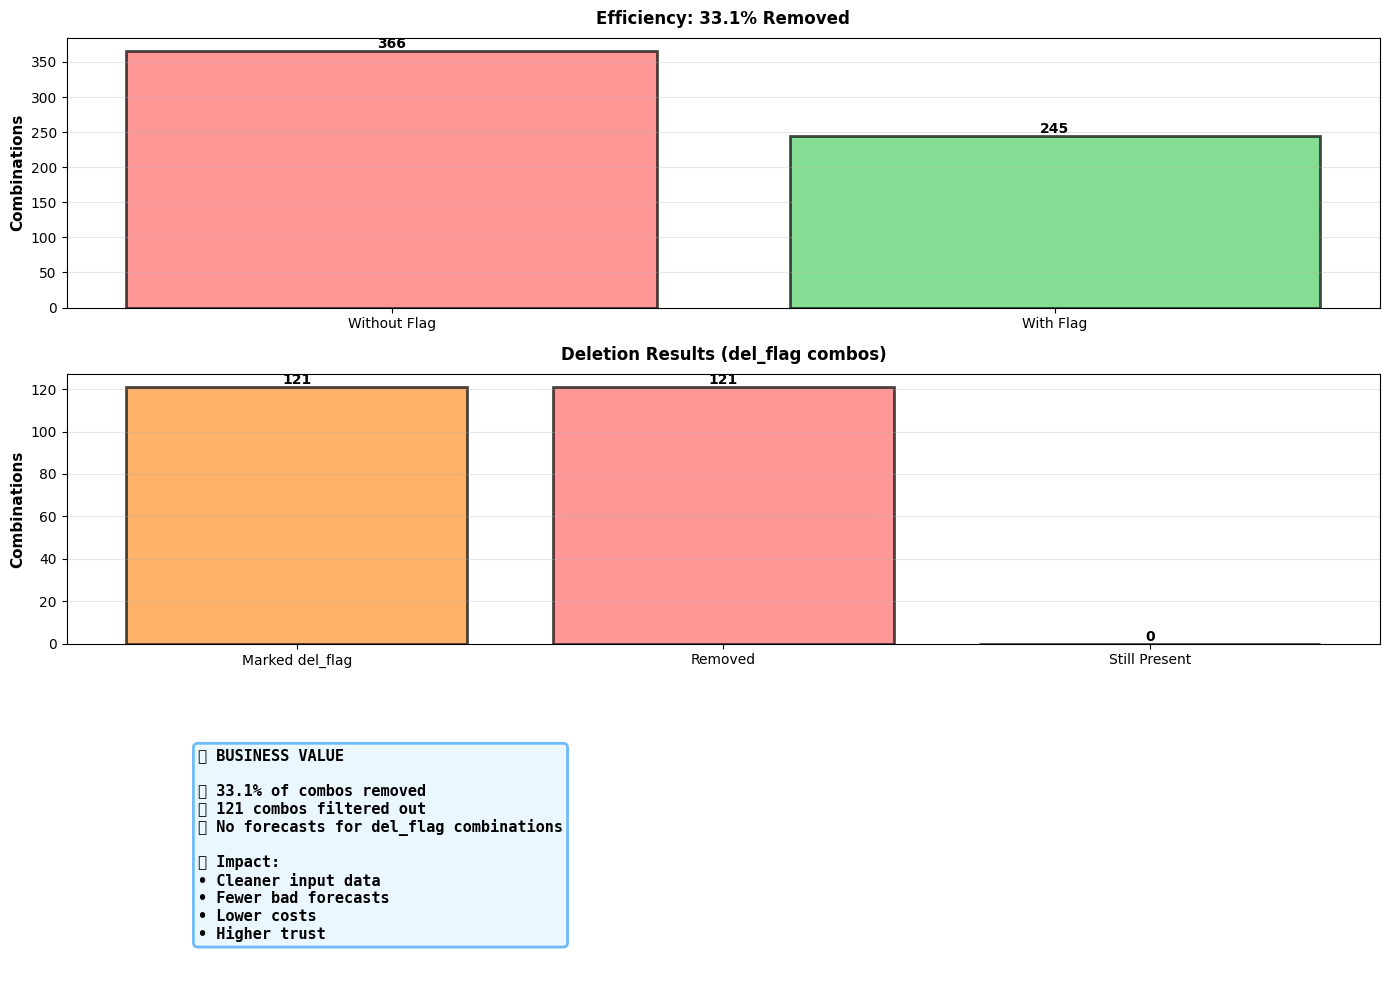

In [15]:
# Business impact summary based on filtering results

# Guard against divide-by-zero
if total_input_combos == 0:
    total_input_combos = 1
if total_output_combos < 0:
    total_output_combos = 0

# Clamp filtered_count to non-negative and not exceeding total_input_combos
invalid_combos_count = max(0, min(filtered_count, total_input_combos))
valid_combos_count = max(0, min(total_output_combos, total_input_combos))
total_possible_combos = total_input_combos
savings_pct = (invalid_combos_count/total_possible_combos*100) if total_possible_combos > 0 else 0

fig, axes = plt.subplots(3, figsize=(14, 10))

ax1 = axes[0]
eff_data = {
    'Without Flag': total_possible_combos,
    'With Flag': valid_combos_count
}
bars1 = ax1.bar(eff_data.keys(), eff_data.values(), color=['#ff6b6b', '#51cf66'], 
                alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Combinations', fontsize=11, fontweight='bold')
ax1.set_title(f'Efficiency: {savings_pct:.1f}% Removed', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax3 = axes[1]
problems = ['Marked del_flag', 'Removed', 'Still Present']
values = [total_del_combos, min(invalid_combos_count, total_del_combos), irrelevant_after_count]
bars3 = ax3.bar(problems, values, color=['#ff922b', '#ff6b6b', '#fab005'], alpha=0.7, 
                edgecolor='black', linewidth=2)
ax3.set_ylabel('Combinations', fontsize=11, fontweight='bold')
ax3.set_title('Deletion Results (del_flag combos)', fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax4 = axes[2]
ax4.axis('off')
benefits_text = f"""💰 BUSINESS VALUE

✅ {savings_pct:.1f}% of combos removed
✅ {invalid_combos_count:,} combos filtered out
✅ No forecasts for del_flag combinations

📊 Impact:
• Cleaner input data
• Fewer bad forecasts
• Lower costs
• Higher trust"""
ax4.text(0.1, 0.5, benefits_text, fontsize=11, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#e7f5ff', alpha=0.8, edgecolor='#4dabf7', linewidth=2),
         family='monospace', fontweight='bold')

plt.tight_layout()
plt.show()
